## Music League Stats

All of the data is scraped into a pandas dataframe with each row being an entry, with submitter name, song id, votes from all other players, and other stats scraped from the spotify API.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from itertools import repeat

import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.dates as mdates


from scraper import translator, create_dataframe
from spotify_data import get_spotify_data, get_playlist, playlists

Dump the files from the downloaded webpage into `/music_league/` in the root of this directory. It has to be the full html and media download, just html doesn't contain the voting information unfortunately.

In [2]:
path = Path("../music_league_2/")

df, names = create_dataframe(path=path, translator=translator) # translator is a dictionary that converts music league names to actual names
df = get_spotify_data(music_league_df=df)

In [3]:
round_names = (
    "Boxing Entrance",
    "Best Sample",
    "Best Live Version",
    "Obscurity",
    "Best solo breakout",
    "Best summer song",
    "To the Polls",
    "Song with a drink in the title",
    "One hit wonder",
    "Riskaware anthem"
)

df["round_name"] = df["round"].astype(int).map(lambda i: round_names[i-1])

In [4]:
winning_order = df.groupby(df["submitter"])[names].sum().sum(axis=1)
winning_order = winning_order.sort_values(ascending=False).index

df["round_score"] = df[names].sum(axis=1)

# Round winners

for round_name, (round, scores) in zip(round_names, df.groupby("round")):
    winning_score = scores["round_score"].max()
    a = f"Round {round:<4} | {round_name}"
    print(a + "\n" + '-'*len(a))
    for _, row in scores[scores["round_score"] == winning_score][["submitter", "track_name", "round_score"]].iterrows():
        print(f"{row['submitter']:10} | {row['track_name']:40} | {int(row['round_score'])}")
    print()


Round 1    | Boxing Entrance
----------------------------
Martha     | X Gon' Give It To Ya                     | 23

Round 2    | Best Sample
------------------------
Jamie      | Stan                                     | 19

Round 3    | Best Live Version
------------------------------
Jenny S    | The Man Who Sold The World - Live        | 23

Round 4    | Obscurity
----------------------
Jamie      | Sweet Reprieve                           | 16
Helen      | Pictures                                 | 16

Round 5    | Best solo breakout
-------------------------------
Helen      | Edge of Seventeen                        | 20

Round 6    | Best summer song
-----------------------------
Martha     | Mas Que Nada                             | 21

Round 7    | To the Polls
-------------------------
Martha     | Zombie                                   | 19

Round 8    | Song with a drink in the title
-------------------------------------------
Helen      | Black Coffee                

## Biggest scores per round

In [5]:
df.sort_values("round_score", ascending=False).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

,round_name,submitter,track_name,round_score
0,Boxing Entrance,Martha,X Gon' Give It To Ya,23.0
61,Best Live Version,Jenny S,The Man Who Sold The World - Live,23.0
123,Best summer song,Martha,Mas Que Nada,21.0
102,Best solo breakout,Helen,Edge of Seventeen,20.0
20,Riskaware anthem,Mark,We Care a Lot,19.0
41,Best Sample,Jamie,Stan,19.0
143,To the Polls,Martha,Zombie,19.0
62,Best Live Version,Martha,Burning Down the House - Live,18.0
63,Best Live Version,Bethany,Lapdance (Live),18.0
164,Song with a drink in the title,Helen,Black Coffee,18.0


In [6]:
df.sort_values("round_score", ascending=True).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

,round_name,submitter,track_name,round_score
80,Best Live Version,Olek,Final - Live Version - Rappel,-13.0
163,To the Polls,Sam,Do They Know It's Christmas? - 1984 Version,-11.0
40,Riskaware anthem,Fred,Funny Little Man,-11.0
122,Best solo breakout,Tim C,Paranoid (2012 - Remaster),-10.0
184,Song with a drink in the title,Mark,Tubthumping,-8.0
101,Obscurity,Olek,Phobia - Live,-7.0
204,One hit wonder,Olek,Love Is All I Got,-6.0
162,To the Polls,Olek,Woman,-6.0
121,Best solo breakout,Sam,Wonderful Christmastime - Full Length Version ...,-6.0
183,Song with a drink in the title,Mel,151 Rum,-5.0


## Voting Matrix

The voting matrix shows the net votes of all competitors across all of the rounds. Rows are the points received, columns the points given. The rows and columns are sorted into the final order of the league

In [7]:
# arr has shape (num_rounds, num_competitors, num_competitors)
# Any missing values are filled with 0.0

arr = np.concatenate([
        group.reindex(winning_order, fill_value=0.0).to_numpy()[None, :, :]
        for _, group in df.set_index(df["submitter"]).groupby("round")[winning_order]], axis=0)
correlation = np.sum(arr, axis=0)

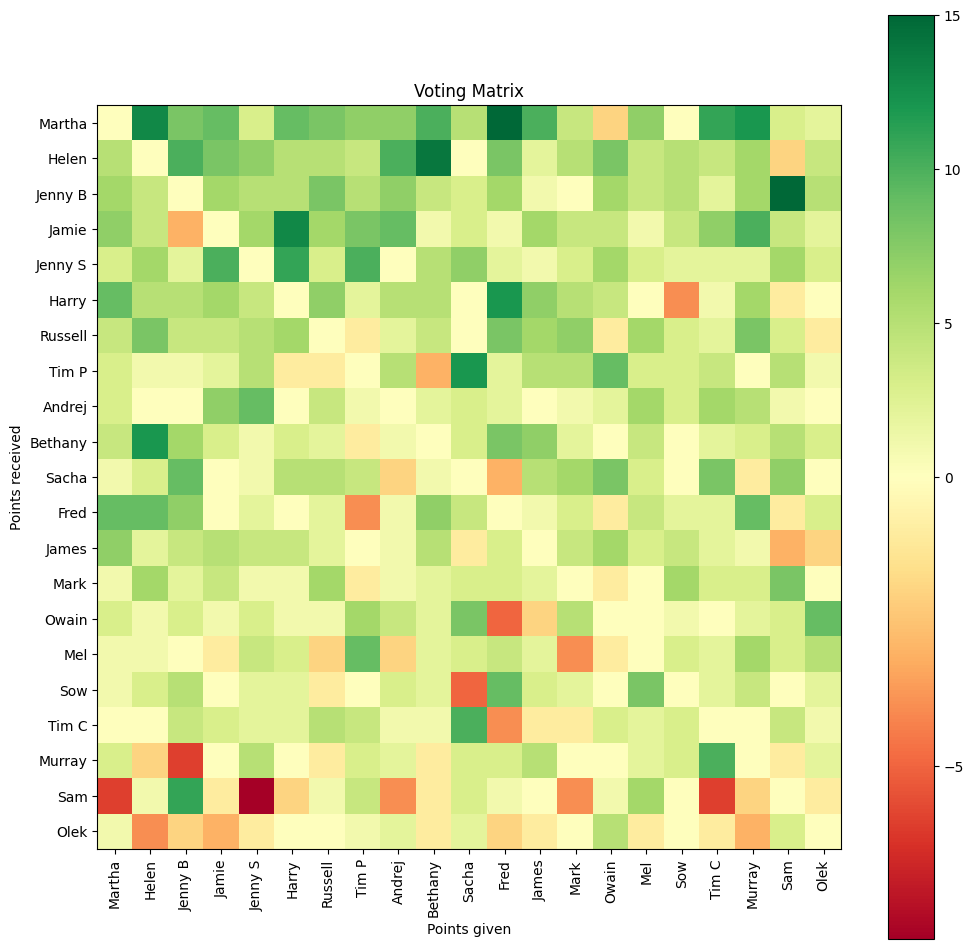

In [8]:
fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(correlation),
                        vcenter=0,
                        vmax=np.max(correlation))

plt.imshow(correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.xlabel("Points given")
plt.ylabel("Points received")
plt.title("Voting Matrix")


cbar = plt.colorbar()

plt.show()

List the top ten biggest stans and haters

In [9]:
biggest_stans = np.unravel_index(np.argsort(-correlation.reshape(-1))[:10], correlation.shape)
for row, col in zip(*biggest_stans):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(correlation[row, col])}")


Fred for Martha: 15
Sam for Jenny B: 15
Bethany for Helen: 14
Helen for Martha: 13
Harry for Jamie: 13
Murray for Martha: 12
Sacha for Tim P: 12
Fred for Harry: 12
Helen for Bethany: 12
Harry for Jenny S: 11


In [10]:
biggest_haters = np.unravel_index(np.argsort(correlation.reshape(-1))[:10], correlation.shape)
for row, col in zip(*biggest_haters):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(correlation[row, col])}")


Jenny S for Sam: -8
Jenny B for Murray: -6
Martha for Sam: -6
Tim C for Sam: -6
Sacha for Sow: -5
Fred for Owain: -5
Mark for Mel: -4
Tim P for Fred: -4
Sow for Harry: -4
Fred for Tim C: -4


## Voting Correlation

See who votes similarly... and who doesn't

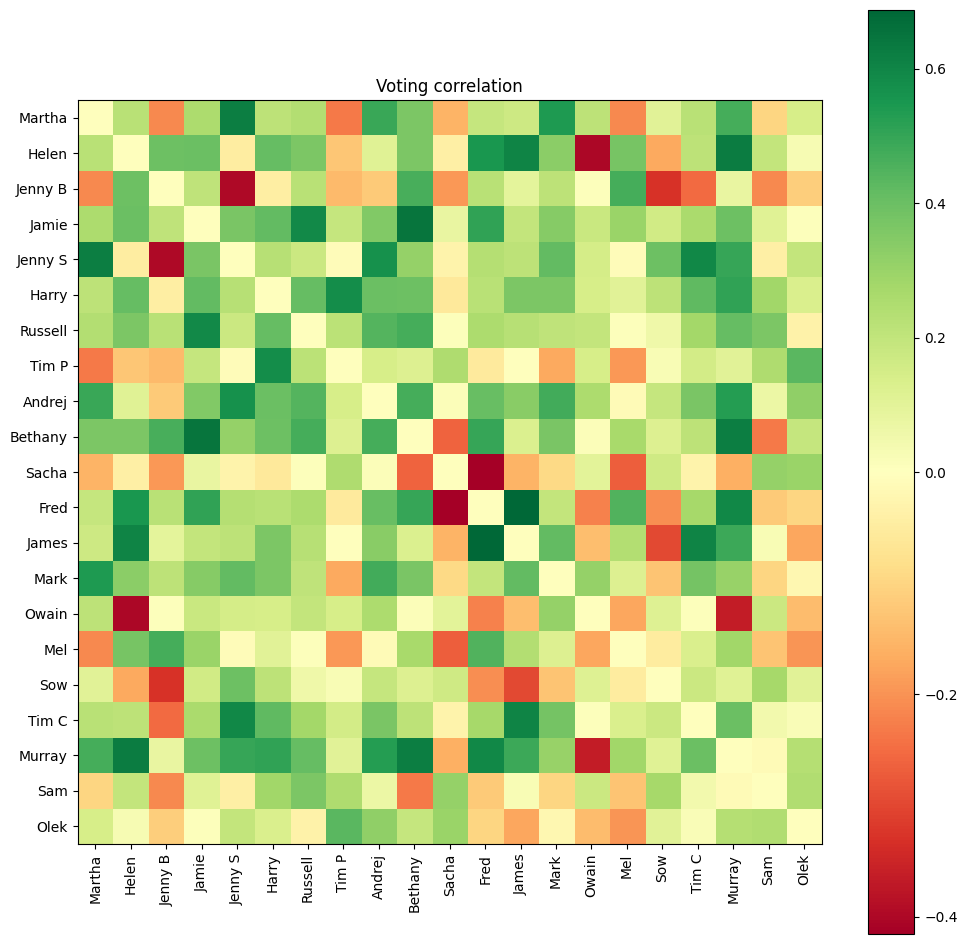

In [11]:
# Sort arr into an array that's lists of each competitors votes per round

voting_correlation = np.corrcoef(np.vstack(correlation).T)
np.fill_diagonal(voting_correlation, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_correlation),
                        vcenter=0,
                        vmax=np.max(voting_correlation))

plt.imshow(voting_correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.title("Voting correlation")


cbar = plt.colorbar()

plt.show()

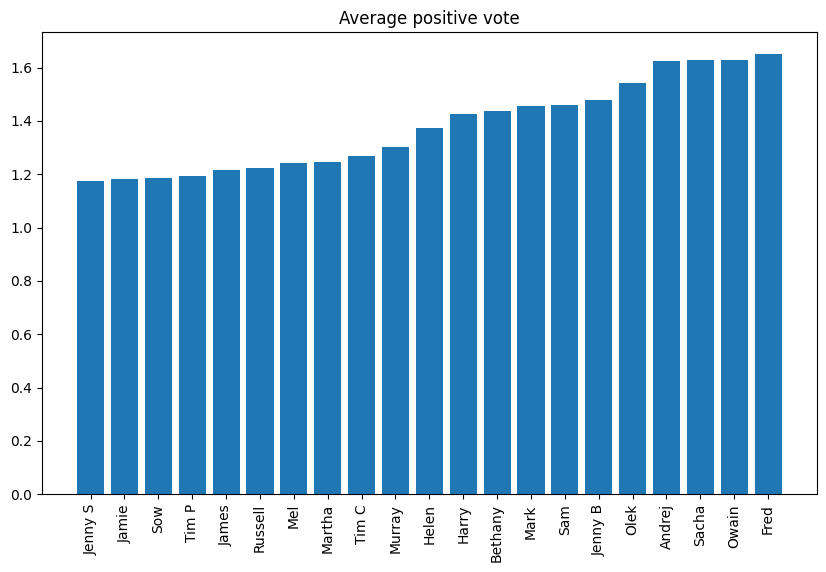

In [12]:
x = arr.reshape(-1, len(winning_order))
x[x <= 0.0] = np.nan
a = np.nanmean(x, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Average positive vote")

ax.bar(np.arange(len(winning_order)), a[np.argsort(a)])
ax.set_xticks(np.arange(len(winning_order)), labels=[winning_order[i] for i in np.argsort(a)], rotation="vertical")

plt.show()

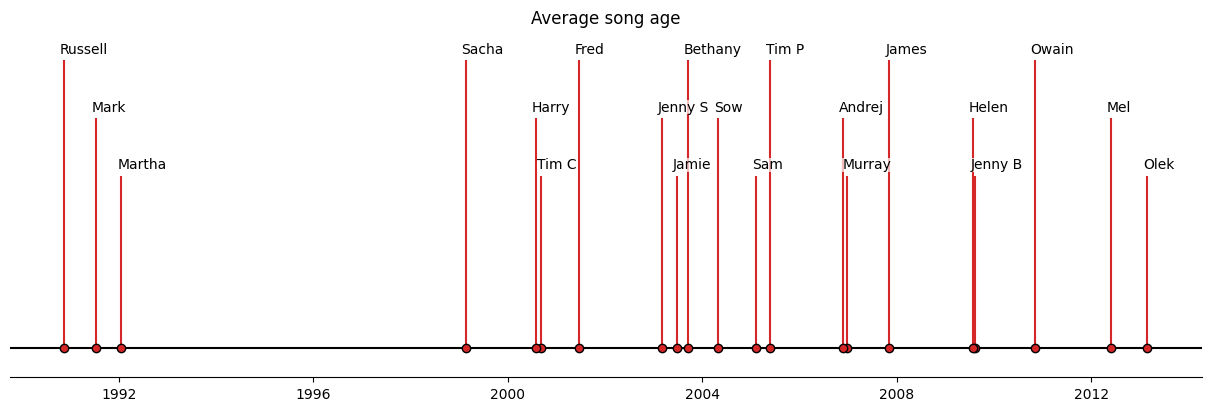

In [34]:
# Average song age

df["song_age_seconds"] = (datetime.now() - df["date"]).dt.total_seconds()
ages = df.groupby("submitter")["song_age_seconds"].mean().sort_values().map(lambda x: datetime.now() - timedelta(seconds=x))

fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
ax.set(title="Average song age")

levels = [(i % 3) / 3 + 1 for i in range(len(ages))]

# The vertical stems.
ax.vlines(ages, 0, levels,
          color=[("tab:red", 1)
                 for _ in ages])
# The baseline.
ax.axhline(0, c="black")
# The markers on the baseline
ax.plot(ages, np.zeros_like(ages), "ko", mfc="tab:red")

# Annotate the lines.
for date, level, name in zip(ages, levels, ages.index):
    ax.annotate(name, xy=(date, level),
                xytext=(-3, np.sign(level)*3), textcoords="offset points",
                verticalalignment="bottom" if level > 0 else "top",
                bbox=dict(boxstyle='square', pad=0, lw=0, fc=(1, 1, 1, 0.7)))

ax.yaxis.set(major_locator=mdates.YearLocator(),
             major_formatter=mdates.DateFormatter("%Y"))

# Remove the y-axis and some spines.
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()

In [41]:
# Does song age correlate with overall ranking?

np.corrcoef(np.c_[ages.reindex(winning_order).argsort(), np.arange(len(ages))].T)

array([[1.        , 0.28961039],
       [0.28961039, 1.        ]])

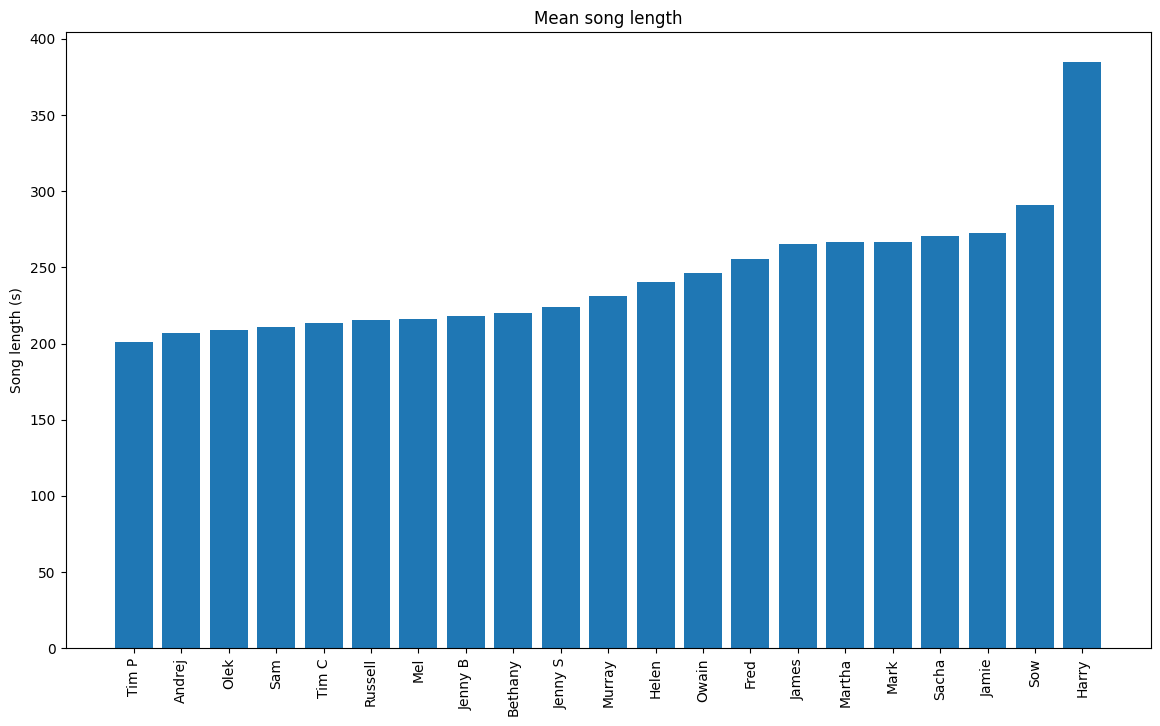

In [33]:
lengths = df.groupby("submitter")["duration"].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 8))

ax.bar(np.arange(len(lengths)), lengths)
ax.set_xticks(np.arange(len(winning_order)), lengths.index, rotation='vertical')
ax.set_title("Mean song length")
ax.set_ylabel("Song length (s)")
plt.show()

In [15]:
df.sort_values("duration", ascending=False)[["submitter", "track_name", "duration"]].iloc[:10]

,submitter,track_name,duration
75,Harry,"The Curtain - Live From Dordrecht, Het Energie...",909.106
150,Harry,Zombie,745.653
153,Mel,Hurricane,512.732
70,Sow,Recurring/We Could Forever - Live,479.573
97,Mark,"Given Up - Original 12"" Mix",464.000
35,Martha,Computer Love - 2009 Remaster,439.440
124,Harry,Hot Hot Hot,404.426
41,Jamie,Stan,404.106
200,James,Music Sounds Better With You,403.293
88,Sow,Sweetness Is My Weakness,390.413


In [16]:
df[df["round"]!=8].sort_values("duration")[["submitter", "track_name", "duration"]].iloc[:10]

,submitter,track_name,duration
12,Tim P,Theme from Strictly Come Dancing,42.000
99,Sam,Fire Alarm,85.395
151,Tim C,Tory Is A 4 Letter Word Pt II,100.586
23,Andrej,Cut Every Corner,109.275
26,Mel,Got The Autism,115.384
17,Bethany,Nervous Breakdown,129.173
145,Jenny B,We Live Here,131.876
140,Sam,The Spark,146.384
92,Mel,Why They Do That?,148.480
148,Jamie,For What It's Worth,153.693


In [17]:
# Energy

df.groupby("submitter")["energy"].mean().sort_values(ascending=False)

submitter
Sacha      0.862400
Helen      0.842400
Tim P      0.829100
Mark       0.812571
Owain      0.805900
Bethany    0.797100
Jenny B    0.781700
Jenny S    0.772800
Olek       0.770700
James      0.762500
Mel        0.751200
Tim C      0.731200
Sow        0.715250
Russell    0.714400
Fred       0.710900
Murray     0.704230
Martha     0.701700
Sam        0.643100
Harry      0.641800
Andrej     0.640200
Jamie      0.636200
Name: energy, dtype: float64

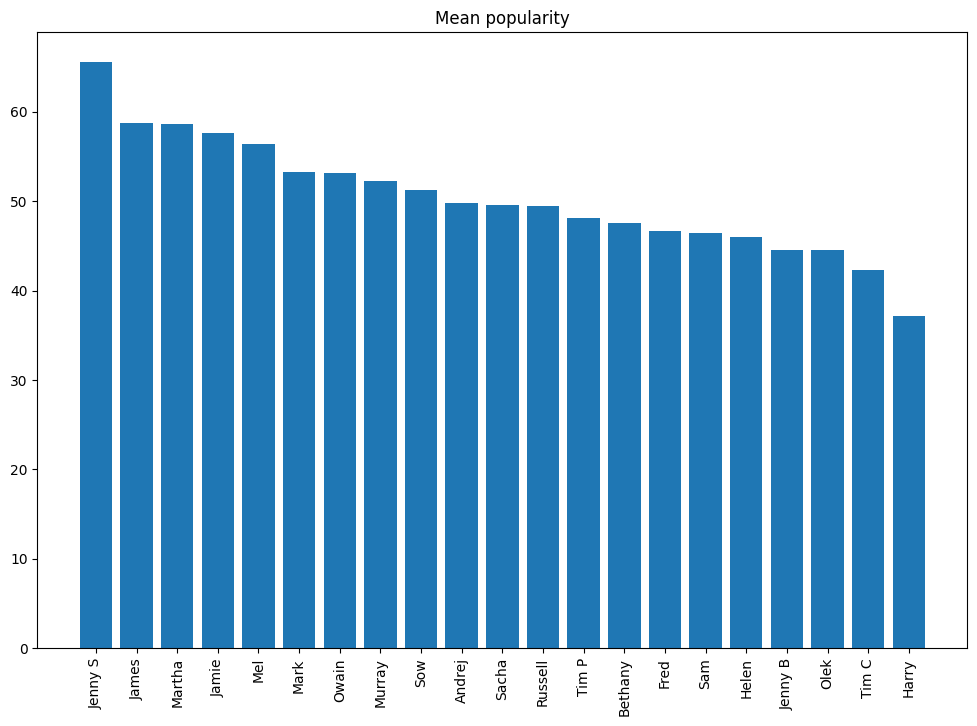

In [18]:
# popularity

fig, ax = plt.subplots(figsize=(12, 8))

pop = df.groupby("submitter")["popularity"].mean().sort_values(ascending=False)
ax.bar(range(len(pop)), pop)
ax.set_xticks(range(len(pop)), pop.index, rotation="vertical")


ax.set_title("Mean popularity")

plt.show()

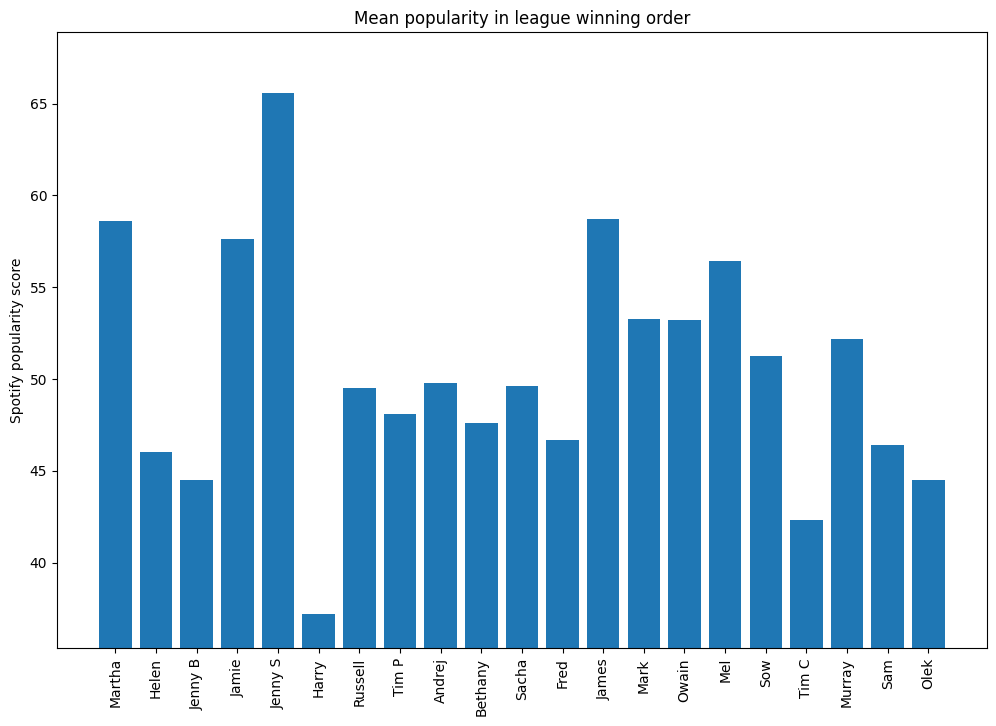

In [43]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(pop)), pop.reindex(winning_order))
ax.set_xticks(range(len(pop)), winning_order, rotation="vertical")
ax.set_ylim(min(pop)*0.95, max(pop)*1.05)
ax.set_ylabel("Spotify popularity score")

plt.title("Mean popularity in league winning order")

plt.show()

In [20]:
playlists = [get_playlist(playlist) for playlist in playlists]

In [21]:
i, a = list(df.groupby("round"))[0]

vals = []

for i, a in df.groupby("round"):
    vals.append(a.sort_values("round_score", ascending=False)["song_id"].map(lambda x: playlists[i-1].index(x)))

vals[0]

0      8
1      2
2      3
3      5
4     14
5      7
6     17
7      6
8     18
10     4
9     21
11    20
12     9
13     0
14    15
15    12
16    22
17    13
18    16
19    10
Name: song_id, dtype: int64

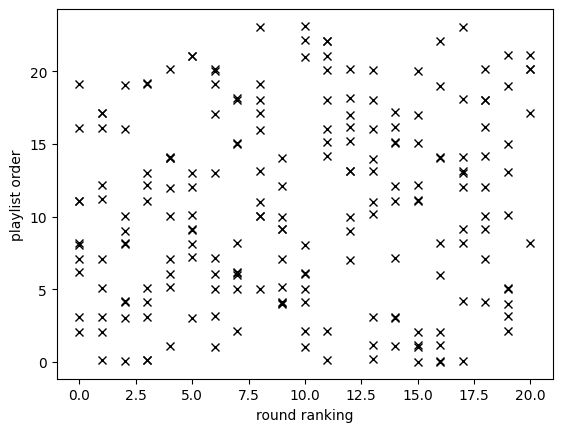

In [50]:
rankings = np.array([i for df in vals for i in range(len(df))])
playlist_order = np.array([i for df in vals for i in df.values])

# Add noise
playlist_order = playlist_order + np.random.random(*playlist_order.shape) * 0.2

plt.xlabel("round ranking")
plt.ylabel("playlist order")

plt.plot(rankings, playlist_order, "kx")
plt.show()


In [23]:
np.corrcoef(rankings, playlist_order)

array([[1.        , 0.11927457],
       [0.11927457, 1.        ]])

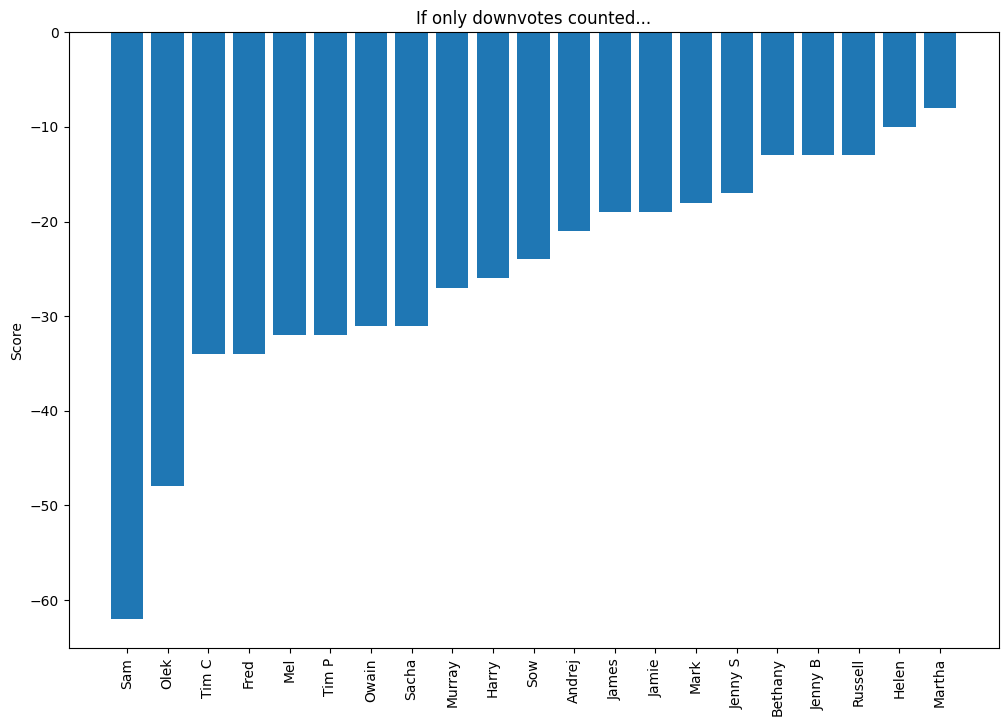

In [61]:
negative_votes = np.where(arr < 0, arr, 0)

negative_scores = np.sum(negative_votes, axis=(0, 2))

order = np.argsort(negative_scores)

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(winning_order)), np.sort(negative_scores))
ax.set_xticks(range(len(winning_order)), winning_order[order], rotation="vertical")
ax.set_ylabel("Score")
ax.set_title("If only downvotes counted...")

plt.show()


c:\music-league-stats\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


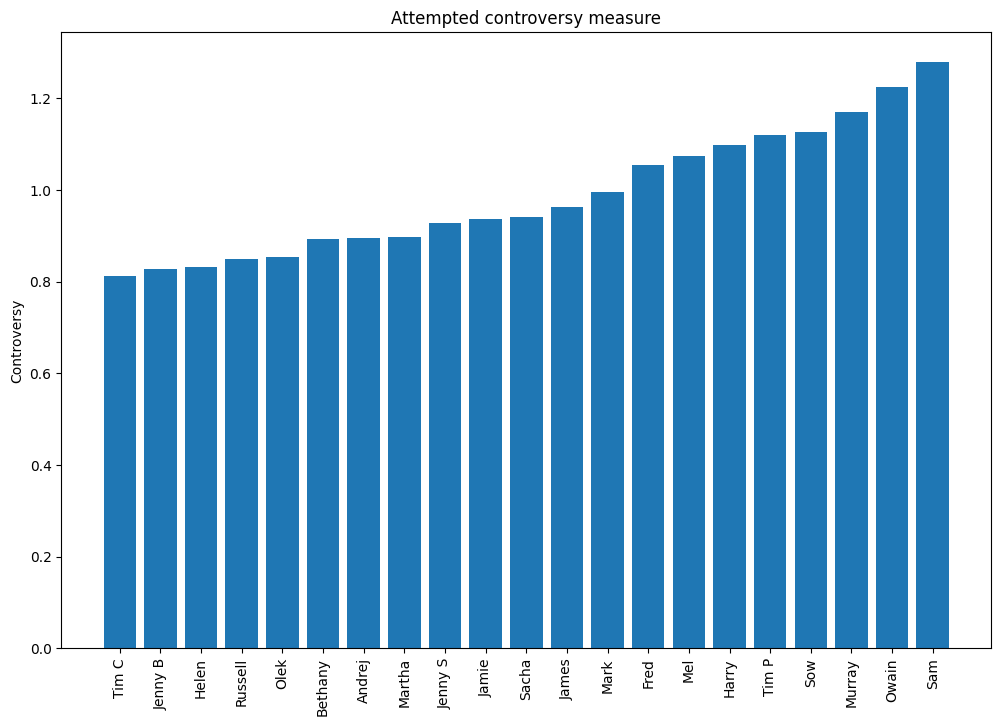

In [74]:
ignore_zeros = np.where(arr == 0, np.nan, arr)
stds = np.nanstd(ignore_zeros, axis=-1)
controversy = np.nanmean(stds, axis=0)

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(winning_order)), sorted(controversy))
ax.set_xticks(range(len(winning_order)), winning_order[np.argsort(controversy)], rotation="vertical")
ax.set_ylabel("Controversy")
ax.set_title("Attempted controversy measure")

plt.show()

In [98]:
x = np.where(df[winning_order].to_numpy() == 0, np.nan, df[winning_order].to_numpy())
df["controversy"] = np.nanstd(x, axis=1)
df.sort_values("controversy", ascending=False)[["submitter", "track_name", "controversy"]].iloc[:10]

,submitter,track_name,controversy
133,Sacha,My Own Summer (Shove It),2.061052
203,Sam,Imagine - Remastered 2010,1.963203
137,Murray,Knee Deep (feat. Jimmy Buffett),1.939072
94,Owain,Mask Of Lies,1.854050
197,Harry,Under Me Sleng Teng,1.851640
22,Jenny B,The Creativity Song,1.817079
4,Mel,Horns,1.763342
74,Mel,Cherry Wine - Live,1.688194
55,Bethany,Gimme Some More,1.632993
73,Tim P,"Free Fallin' - Live at the Nokia Theatre, Los ...",1.610913


In [116]:
arr = np.concatenate([
        group.reindex(winning_order, fill_value=0.0).to_numpy()[None, :, :]
        for _, group in df.set_index(df["submitter"]).groupby("round")[winning_order]], axis=0)

positive = np.where(arr > 0.0, arr, np.nan)
negative = np.where(arr < 0.0, arr, np.nan)

positive_scores = np.nansum(positive, axis=(-1))
negative_scores = np.nansum(negative, axis=(-1))



